<a href="https://colab.research.google.com/github/roblero-gunn/Proyecto1_CoffeeLeafs/blob/main/dev_model/DINOv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Vision Transformer DINOv2 (Meta)***

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split,  Subset
import time

import torchvision
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights
import shutil

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
import copy
from tqdm import tqdm

import random

from torch.utils.data import Subset, DataLoader, WeightedRandomSampler
import torchvision.models as models

from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

import seaborn as sns
from sklearn.metrics import confusion_matrix

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cpu
CUDA disponible: False


In [7]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Carga del Dataset

In [2]:
from google.colab import drive

# Esto montará tu Google Drive en la carpeta virtual de Colab
drive.mount('/content/drive')
print("Google Drive conectado exitosamente.")

Mounted at /content/drive
Google Drive conectado exitosamente.


In [3]:
from google.colab import drive
# El force_remount=True obliga a Colab a reparar la conexión rota
drive.mount('/content/drive', force_remount=True)
print("Conexión con Drive restablecida.")

Mounted at /content/drive
Conexión con Drive restablecida.


In [4]:
# Rutas
ruta_zip_drive = "/content/drive/MyDrive/Dataset_Maestro_RoCoLe.zip"
ruta_zip_local = "/content/Dataset_Maestro_RoCoLe.zip"
carpeta_destino = "/content/Dataset_Maestro_RoCoLe"

if os.path.exists(ruta_zip_drive):
    # 1. Copiar el ZIP completo desde Drive a la memoria rápida (Evita el error 107)
    print("1/2: Copiando el archivo ZIP desde Drive a Colab (esto tomará unos segundos)...")
    shutil.copy2(ruta_zip_drive, ruta_zip_local)

    # 2. Descomprimir el archivo que ya está 100% en la memoria local
    print("2/2: Descomprimiendo el archivo local...")
    shutil.unpack_archive(ruta_zip_local, carpeta_destino)

    print(f"¡Éxito total! Tu dataset está listo en la carpeta '{carpeta_destino}'.")

    # Opcional: Borrar el ZIP local para liberar espacio en RAM
    os.remove(ruta_zip_local)
else:
    print(f"Error: No se encontró el ZIP en Drive. Asegúrate de que siga ahí.")

1/2: Copiando el archivo ZIP desde Drive a Colab (esto tomará unos segundos)...
2/2: Descomprimiendo el archivo local...
¡Éxito total! Tu dataset está listo en la carpeta '/content/Dataset_Maestro_RoCoLe'.


# Carga DINOv2

In [ ]:
!pip install xformers

In [12]:
class ClasificadorCafeDino(nn.Module):
    def __init__(self, num_clases=4):
        super().__init__()
        # Cargar DinoV2 Small
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

        # Congelar el backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Crear la cabeza de clasificación (DinoV2 Small saca vectores de 384)
        self.cabeza_clasificacion = nn.Linear(384, num_clases)

    def forward(self, x):
        caracteristicas = self.backbone(x)
        resultado = self.cabeza_clasificacion(caracteristicas)
        return resultado

# Instanciar y enviar a GPU
modelo_transfer = ClasificadorCafeDino(num_clases=len(train_base.classes)).to(device)

# Pérdida y Optimizador (Solo entrena la cabeza nueva)
criterion = nn.CrossEntropyLoss()
optimizer_transfer = torch.optim.Adam(modelo_transfer.cabeza_clasificacion.parameters(), lr=1e-3)

print("¡Modelo DinoV2 configurado y listo!")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


¡Modelo DinoV2 configurado y listo!


# Dividir en train/val/test con balance de clases

In [13]:
# Configurar dispositivo (GPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

# Transformaciones (DinoV2 requiere parches múltiplos de 14, así que 224 es perfecto)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Cargar base de datos
#carpeta_destino = "/content/Dataset_Maestro_RoCoLe"
train_base = datasets.ImageFolder(root=carpeta_destino, transform=train_transforms)
val_base = datasets.ImageFolder(root=carpeta_destino, transform=val_test_transforms)

# División 70/20/10
num_imagenes = len(train_base)
indices = torch.randperm(num_imagenes, generator=torch.Generator().manual_seed(42)).tolist()

train_size = int(0.70 * num_imagenes)
test_size = int(0.20 * num_imagenes)
val_size = num_imagenes - train_size - test_size

train_dataset = Subset(train_base, indices[:train_size])
test_dataset = Subset(val_base, indices[train_size : train_size + test_size])
val_dataset = Subset(val_base, indices[train_size + test_size:])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Clases encontradas: {train_base.classes}")
print(f"Imágenes -> Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Entrenando en: cpu
Clases encontradas: ['Ojo_Gallo', 'Roya', 'Sanas', 'red_spider_mite']
Imágenes -> Train: 1158 | Val: 166 | Test: 331


# Entrenamiento / EarlyStopping
## 40 épocas y tolerancia de 5

In [14]:
num_epochs = 40

best_val_loss = float('inf')
paciencia = 5   # Tolerancia de 5 épocas sin mejorar
epochs_sin_mejora = 0

'''
 AGREGADO 1: El "cuaderno" para guardar el historial
'''
historial_train_loss = []
historial_val_loss = []
historial_train_acc = []
historial_val_acc = []

print("Iniciando DinoV2...\n")

for epoch in range(num_epochs):
    start_time = time.time()

    # --- ENTRENAMIENTO ---
    modelo_transfer.train()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_transfer.zero_grad()

        outputs = modelo_transfer(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_transfer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    # --- VALIDACIÓN ---
    modelo_transfer.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = modelo_transfer(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(val_dataset)
    val_epoch_acc = val_corrects.double() / len(val_dataset)

    '''
     AGREGADO 2: Anotar los resultados en las listas
     (Se usa .item() para sacar el número puro del tensor de PyTorch)
    '''
    historial_train_loss.append(epoch_loss)
    historial_val_loss.append(val_epoch_loss)
    historial_train_acc.append(epoch_acc.item())
    historial_val_acc.append(val_epoch_acc.item())

    # --- RESULTADOS ---
    epoch_mins, epoch_secs = divmod(time.time() - start_time, 60)
    print(f'Época {epoch+1:02d}/{num_epochs} | {int(epoch_mins)}m {int(epoch_secs)}s')
    print(f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}')
    print(f'Val Loss:   {val_epoch_loss:.4f} | Val Acc:   {val_epoch_acc:.4f}')

    # --- EARLY STOPPING ---
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        epochs_sin_mejora = 0
        torch.save(modelo_transfer.state_dict(), '/content/mejor_modelo_dinov2.pth')
        print(" ¡Nuevo mejor modelo guardado!")
    else:
        epochs_sin_mejora += 1
        print(f" Sin mejora. Paciencia: {epochs_sin_mejora}/{paciencia}")
        if epochs_sin_mejora >= paciencia:
            print(f"\n EARLY STOPPING: El modelo dejó de mejorar tras {epoch+1} épocas.")
            break
    print('-' * 40)

print("¡Entrenamiento Finalizado!")

Iniciando DinoV2...

Época 01/40 | 2m 11s
Train Loss: 0.5926 | Train Acc: 0.8074
Val Loss:   0.3817 | Val Acc:   0.8494
 ¡Nuevo mejor modelo guardado!
----------------------------------------
Época 02/40 | 2m 7s
Train Loss: 0.1902 | Train Acc: 0.9516
Val Loss:   0.1709 | Val Acc:   0.9398
 ¡Nuevo mejor modelo guardado!
----------------------------------------
Época 03/40 | 2m 9s
Train Loss: 0.1174 | Train Acc: 0.9784
Val Loss:   0.1410 | Val Acc:   0.9518
 ¡Nuevo mejor modelo guardado!
----------------------------------------
Época 04/40 | 2m 7s
Train Loss: 0.0934 | Train Acc: 0.9801
Val Loss:   0.1647 | Val Acc:   0.9398
 Sin mejora. Paciencia: 1/5
----------------------------------------
Época 05/40 | 2m 10s
Train Loss: 0.0762 | Train Acc: 0.9879
Val Loss:   0.1189 | Val Acc:   0.9518
 ¡Nuevo mejor modelo guardado!
----------------------------------------
Época 06/40 | 2m 9s
Train Loss: 0.0747 | Train Acc: 0.9836
Val Loss:   0.1213 | Val Acc:   0.9518
 Sin mejora. Paciencia: 1/5
----

# Guardar Modelo

In [15]:
ruta_temporal = '/content/mejor_modelo_dinov2.pth'
ruta_drive = '/content/drive/MyDrive/mejor_modelo_dinov2.pth'

# Copiar el archivo de la memoria que se borra, a tu Drive seguro
shutil.copy2(ruta_temporal, ruta_drive)
print("¡Modelo rescatado y respaldado en tu Google Drive con éxito!")

¡Modelo rescatado y respaldado en tu Google Drive con éxito!


# Visualización resultados del entrenamiento

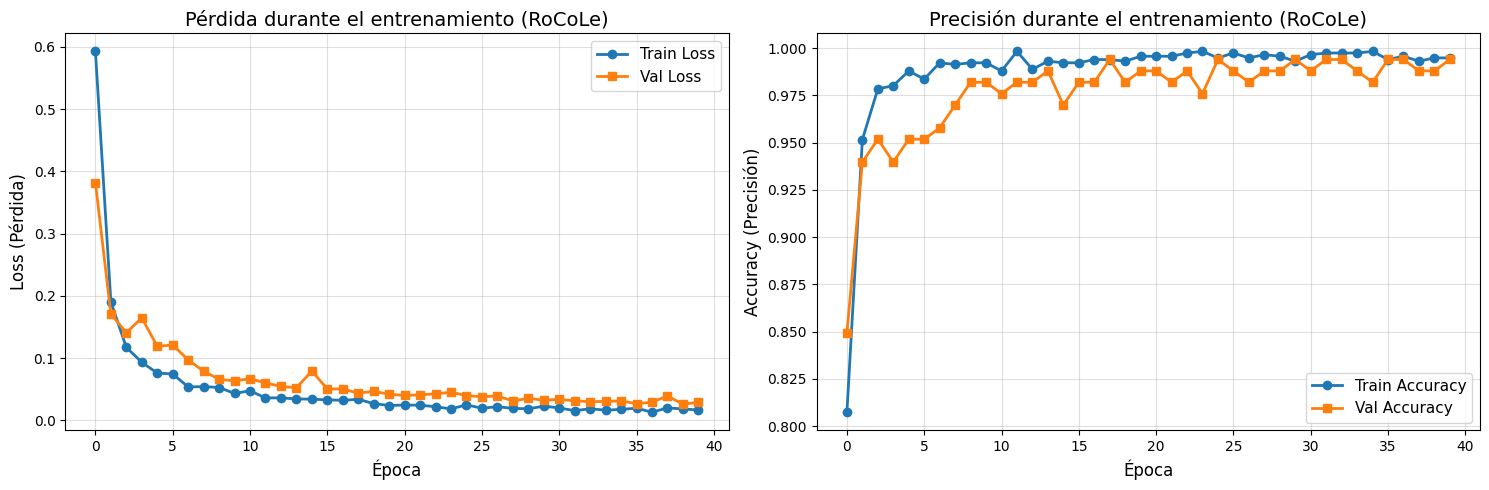


RESULTADOS FINALES DEL ENTRENAMIENTO:
  Última Train Loss: 0.0168
  Última Train Acc:  0.9948
  Última Val Loss:   0.0292
  Última Val Acc:    0.9940
------------------------------------------------------------
MEJOR VAL ACCURACY ALCANZADO: 0.9940


In [16]:
# Crear una figura con dos subgráficos uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Pérdida (Loss)
axes[0].plot(historial_train_loss, label='Train Loss', marker='o', linewidth=2)
axes[0].plot(historial_val_loss, label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Loss (Pérdida)', fontsize=12)
axes[0].set_title('Pérdida durante el entrenamiento (RoCoLe)', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.4)

# Gráfico 2: Precisión (Accuracy)
axes[1].plot(historial_train_acc, label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(historial_val_acc, label='Val Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Accuracy (Precisión)', fontsize=12)
axes[1].set_title('Precisión durante el entrenamiento (RoCoLe)', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.4)

# Ajustar los espacios y mostrar
plt.tight_layout()
plt.show()

# Imprimir resumen numérico
print(f"\n{'='*60}")
print("RESULTADOS FINALES DEL ENTRENAMIENTO:")
print(f"{'='*60}")
print(f"  Última Train Loss: {historial_train_loss[-1]:.4f}")
print(f"  Última Train Acc:  {historial_train_acc[-1]:.4f}")
print(f"  Última Val Loss:   {historial_val_loss[-1]:.4f}")
print(f"  Última Val Acc:    {historial_val_acc[-1]:.4f}")
print("-" * 60)
print(f"MEJOR VAL ACCURACY ALCANZADO: {max(historial_val_acc):.4f}")

# Evaluación del test

In [17]:
def evaluate_model(model, dataloader):
    """Evalúa el modelo en un dataloader y devuelve las predicciones y etiquetas reales."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluando Test'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

print("\n" + "="*60)
print(" EVALUACIÓN FINAL EN CONJUNTO DE TEST (20%)")
print("="*60)

y_true, y_pred = evaluate_model(modelo_transfer, test_loader)

test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"{'='*60}")
print("MÉTRICAS GLOBALES EN TEST:")
print(f"{'='*60}")
print(f"  Accuracy (Exactitud): {test_accuracy:.4f}")
print(f"  Precision:            {test_precision:.4f}")
print(f"  Recall (Sensibilidad):{test_recall:.4f}")
print(f"  F1-Score:             {test_f1:.4f}")

print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN DETALLADO POR CLASE")
print("="*60)
print(classification_report(
    y_true,
    y_pred,
    target_names=train_base.classes,
    zero_division=0
))


 EVALUACIÓN FINAL EN CONJUNTO DE TEST (20%)


Evaluando Test: 100%|██████████| 11/11 [00:32<00:00,  2.94s/it]

MÉTRICAS GLOBALES EN TEST:
  Accuracy (Exactitud): 0.9940
  Precision:            0.9941
  Recall (Sensibilidad):0.9940
  F1-Score:             0.9940

REPORTE DE CLASIFICACIÓN DETALLADO POR CLASE
                 precision    recall  f1-score   support

      Ojo_Gallo       1.00      1.00      1.00        78
           Roya       1.00      0.98      0.99       116
          Sanas       0.98      1.00      0.99       107
red_spider_mite       1.00      1.00      1.00        30

       accuracy                           0.99       331
      macro avg       1.00      1.00      1.00       331
   weighted avg       0.99      0.99      0.99       331



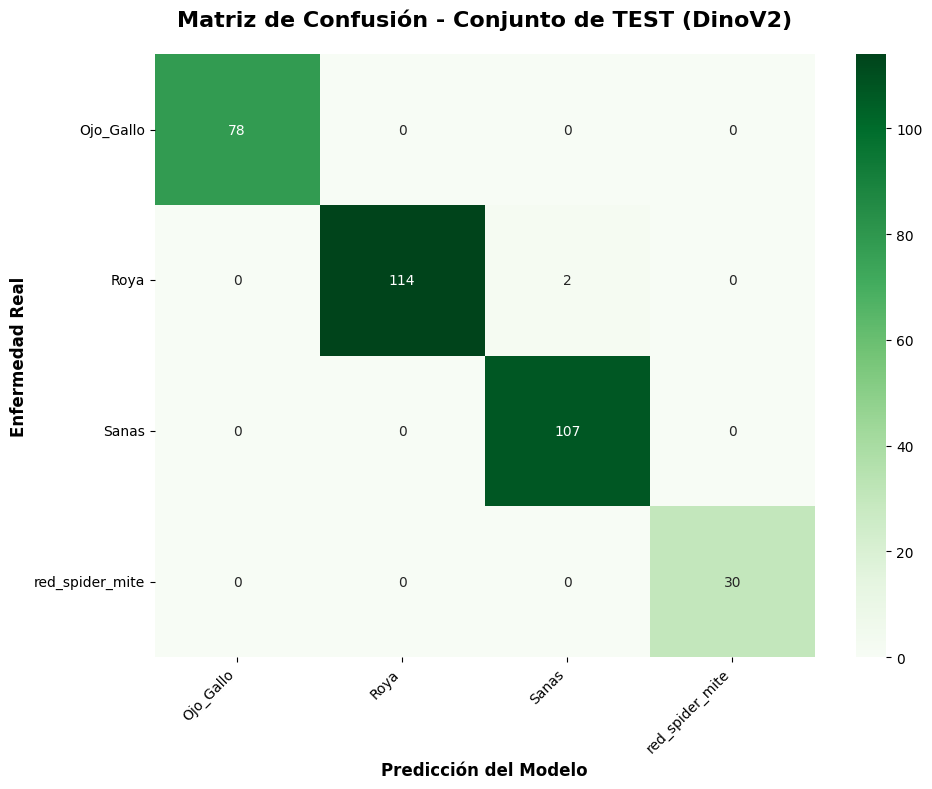


 ACCURACY POR ENFERMEDAD (CONJUNTO DE TEST):
Ojo_Gallo                : 100.00% (78 hojas)
Roya                     : 98.28% (116 hojas)
Sanas                    : 100.00% (107 hojas)
red_spider_mite          : 100.00% (30 hojas)

 VISUALIZACIÓN DE PREDICCIONES EN TEST


In [18]:
# Calcular la matriz de confusión matemáticamente
cm = confusion_matrix(y_true, y_pred)

# Configurar el lienzo
plt.figure(figsize=(10, 8))

# Dibujar el mapa de calor (Heatmap)
sns.heatmap(
    cm,
    annot=True,     # Activado para ver los números exactos
    fmt='d',        # Muestra números enteros
    cmap='Greens',  # El verde es un excelente toque para un proyecto agrícola 🌿
    xticklabels=train_base.classes,
    yticklabels=train_base.classes
)

# Etiquetas y diseño visual
plt.title('Matriz de Confusión - Conjunto de TEST (DinoV2)', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Enfermedad Real', fontsize=12, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Calcular Accuracy desglosado por cada clase
# Diagonal = Aciertos | Sum(axis=1) = Total de hojas reales de esa clase
class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\n" + "="*60)
print(" ACCURACY POR ENFERMEDAD (CONJUNTO DE TEST):")
print("="*60)

for i, acc in enumerate(class_accuracy):
    if not np.isnan(acc):
        count = cm.sum(axis=1)[i]
        print(f"{train_base.classes[i]:25s}: {acc * 100:.2f}% ({int(count)} hojas)")

print("\n" + "="*60)
print(" VISUALIZACIÓN DE PREDICCIONES EN TEST")
print("="*60)


VISUALIZANDO 8 PREDICCIONES AL AZAR (TEST)


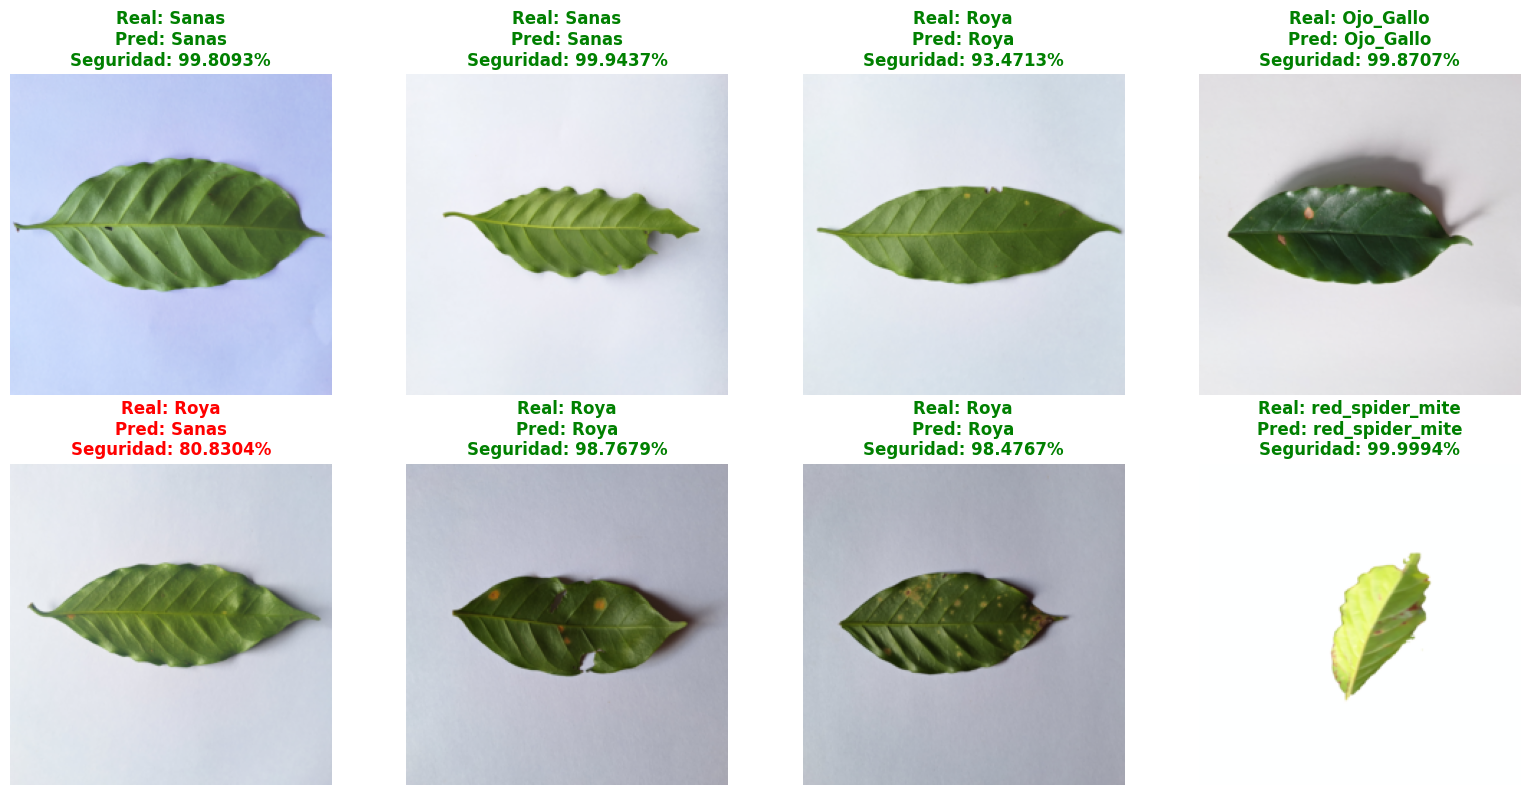

In [36]:
def visualize_random_predictions(model, dataloader, nombres_clases, num_images=8):
    """
    Toma imágenes al azar del dataset, las pasa por el modelo
    y muestra visualmente si acertó o falló.
    """
    model.eval() # Modo evaluación (bloquea el aprendizaje)

    # 1. Obtener el dataset completo que está "dentro" del dataloader
    dataset = dataloader.dataset

    # 2. Elegir índices al azar (ej. si tienes 100 imágenes, elige 8 números al azar)
    indices_aleatorios = random.sample(range(len(dataset)), num_images)

    # Crear un lienzo para 8 imágenes (2 filas x 4 columnas)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    with torch.no_grad():
        for i, idx in enumerate(indices_aleatorios):
            # 3. Extraer una sola imagen y su etiqueta real usando el índice al azar
            img_tensor, label_idx = dataset[idx]

            # PyTorch espera lotes (batches) [batch_size, canales, alto, ancho]
            # Usamos unsqueeze(0) para simular que le mandamos un lote de 1 sola imagen
            input_batch = img_tensor.unsqueeze(0).to(device)

            # Pasar la imagen por el modelo
            output = model(input_batch)

            # Calcular porcentajes
            probabilities = torch.nn.functional.softmax(output, dim=1)
            confidence, prediction = torch.max(probabilities, 1)

            # 4. Desnormalizar la imagen para que se vea con sus colores reales
            img = img_tensor.cpu().numpy().transpose((1, 2, 0))
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            # Dibujar la imagen
            axes[i].imshow(img)
            axes[i].axis('off')

            # Preparar los textos
            true_label = nombres_clases[label_idx]
            pred_label = nombres_clases[prediction.item()]
            conf_pct = confidence.item() * 100

            # Color verde si acertó, rojo si falló
            color = 'green' if prediction.item() == label_idx else 'red'

            # Formato ajustado a 4 decimales
            title = f'Real: {true_label}\nPred: {pred_label}\nSeguridad: {conf_pct:.4f}%'

            axes[i].set_title(title, fontsize=12, color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()

'''
SE EJECUTA LA FUNCIÓN CON NUESTRO MODELO
'''
print("\n" + "="*60)
print("VISUALIZANDO 8 PREDICCIONES AL AZAR (TEST)")
print("="*60)

visualize_random_predictions(
    model=modelo_transfer, # Actualizado al nombre correcto del modelo
    dataloader=test_loader,
    nombres_clases=train_base.classes,
    num_images=8
)